> **초기 로컬 실행 기록입니다.** 사용자 코랩 결과 및 시계열 추가 실험의 최신 설명은 README와 molding_timeseries.ipynb를 확인하세요. 출력은 실제 초기 실행 기록을 그대로 보관했습니다.

# 사출 공정 불량 예측과 검사 기준 분석

**질문:** 불량을 더 찾아내려면 정상 제품을 얼마나 더 검사해야 할까?

KAMP 사출성형기 데이터로 진행하는 CPU 기반 소규모 분석이다. 모델 두 개만 비교하고, 중복 제거·시간 분리·검사 부담·미탐 사례에 집중한다. 

## 실행 방법
1. 이 노트북을 코랩 또는 캐글 노트북으로 가져온다. CPU를 사용한다.
2. `labeled_data.csv` 한 파일을 업로드하거나 캐글 입력 데이터로 연결한다.
3. 아래부터 순서대로 실행한다. 경로를 찾지 못하면 `DATA_PATH`를 직접 지정한다.

가이드북의 전체 딥러닝 실습을 재현하는 프로젝트가 아니다. 입력 파일은 이미 KAMP가 1차 가공한 자료이며, 전처리된 다른 CSV를 합치지 않는다.

In [1]:
# 일반적인 코랩/캐글 환경에는 아래 패키지가 준비되어 있다.
# import 오류가 있는 경우에만 다음 줄의 주석을 해제해 실행한다.
# %pip install pandas numpy scikit-learn matplotlib
from pathlib import Path
import os, sys, json, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, confusion_matrix, precision_recall_curve
from sklearn.inspection import permutation_importance

SEED = 42
INSPECTION_BUDGET = 0.10  # 검증 데이터의 10% 이내. 현장 요구가 아닌 분석용 가정.
DATA_PATH = None  # 예: '/content/labeled_data.csv'
if DATA_PATH is None:
    candidates = [Path('labeled_data.csv'), Path('dataset/labeled_data.csv'),
                  Path('/content/labeled_data.csv')]
    if os.environ.get('MOLDING_DATA_PATH'):
        candidates.insert(0, Path(os.environ['MOLDING_DATA_PATH']))
    if Path('/kaggle/input').exists():
        candidates.extend(Path('/kaggle/input').rglob('labeled_data.csv'))
    existing = list(dict.fromkeys(p.resolve() for p in candidates if p.is_file()))
    if len(existing) == 1:
        DATA_PATH = existing[0]
    elif len(existing) > 1:
        raise ValueError('동명 파일이 여러 개입니다. DATA_PATH를 직접 지정하세요.')
    elif 'google.colab' in sys.modules:
        from google.colab import files
        uploaded = files.upload()
        if 'labeled_data.csv' not in uploaded:
            raise ValueError('labeled_data.csv를 업로드하세요.')
        DATA_PATH = Path('labeled_data.csv')
    else:
        raise FileNotFoundError('labeled_data.csv를 연결하고 DATA_PATH를 지정하세요.')
DATA_PATH = Path(DATA_PATH)
raw = pd.read_csv(DATA_PATH, dtype={'PART_FACT_SERIAL': str})
print('Python:', platform.python_version(), 'pandas:', pd.__version__, 'sklearn:', sklearn.__version__)
print('파일:', DATA_PATH.name, '행/열:', raw.shape)
source_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print('SHA256:', source_sha256)
display(raw[['TimeStamp','PART_NAME','PassOrFail','Injection_Time','Max_Injection_Pressure']].head())

Python: 3.12.14 pandas: 3.0.5 sklearn: 1.9.0
파일: labeled_data.csv 행/열: (7996, 45)
SHA256: e8d375c8e0c2cdfc309baf01ac2203fc2edb6e9728e836119042f9670cd46b51


,TimeStamp,PART_NAME,PassOrFail,Injection_Time,Max_Injection_Pressure
0,2020-10-16 04:57:47,CN7 W/S SIDE MLD'G RH,Y,9.59,141.800003
1,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G RH,Y,9.60,141.800003
2,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G LH,Y,9.60,141.800003
3,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G LH,Y,9.59,141.800003
4,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G RH,Y,9.59,141.800003


## 1. 데이터 품질과 분석 범위

`Y`는 양품, `N`은 불량이다. 여기서는 불량을 1로 변환한다. 가이드북의 설명 표와 실습 코드에는 숫자 라벨 표기 차이가 있으므로 원본 Y/N에서 명시적으로 변환한다.

- 전체 열이 같은 행만 중복 제거한다. 공정 수치가 같다는 이유만으로 다른 생산 건을 지우지 않는다.
- `_id` 충돌이 남으면 임의로 고르지 않고 중단한다.
- 동일 설비 S14의 CN7/RG3 제품만 분석한다. 소수의 다른 설비 제품을 섞지 않는다.
- `Reason`은 검사 이후 불량 사유라 입력에서 제외한다. ID·생산 지시 코드·시간도 모델 입력에서 제외하고 시간과 생산 지시는 분리에 활용한다.
- 0은 센서 미사용일 수도 있다. 모든 0을 결측으로 바꾸지 않고 학습 구간의 상수 열을 제거한다.

,단계,행 수,불량 수,불량 비율
0,원본,7996,71,0.008879
1,완전 중복 제거,5232,60,0.011468
2,S14 CN7/RG3 분석 대상,5230,60,0.011472


완전 중복 제거: 2764


,count,sum,mean
PART_NAME,,,
CN7 W/S SIDE MLD'G LH,1985,10,0.005038
CN7 W/S SIDE MLD'G RH,1989,18,0.009050
"RG3 MOLD'G W/SHLD, LH",628,5,0.007962
"RG3 MOLD'G W/SHLD, RH",628,27,0.042994


,결측 수
Reason,7925


,count,sum
time,,
2020-10-16,375,17
2020-10-19,72,0
2020-10-20,764,0
2020-10-21,82,0
2020-10-22,600,15
2020-10-23,500,10
2020-10-27,628,10
2020-10-29,454,0
2020-10-30,755,0


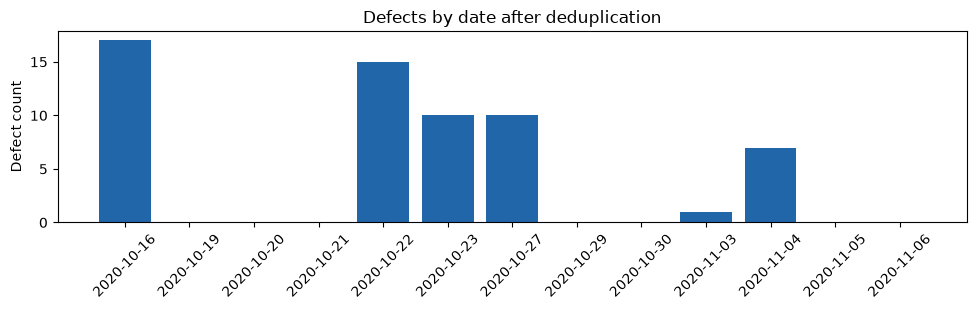

In [2]:
assert set(raw.PassOrFail.unique()) <= {'Y','N'}
duplicate_count = int(raw.duplicated().sum())
clean = raw.drop_duplicates().copy()
assert not clean['_id'].duplicated().any(), '중복 ID를 조사해야 합니다.'
clean['time'] = pd.to_datetime(clean.TimeStamp, errors='raise')
clean['defect'] = clean.PassOrFail.map({'Y':0, 'N':1}).astype(int)
scope = clean.EQUIP_CD.eq('S14') & clean.PART_NAME.str.startswith(('CN7','RG3'))
df = clean.loc[scope].sort_values(['time','_id']).reset_index(drop=True)
audit = pd.DataFrame([
    ['원본',len(raw),int(raw.PassOrFail.eq('N').sum())],
    ['완전 중복 제거',len(clean),int(clean.defect.sum())],
    ['S14 CN7/RG3 분석 대상',len(df),int(df.defect.sum())]
], columns=['단계','행 수','불량 수'])
audit['불량 비율'] = audit['불량 수']/audit['행 수']
display(audit)
print('완전 중복 제거:',duplicate_count)
display(df.groupby('PART_NAME').defect.agg(['count','sum','mean']))
display(raw.isna().sum().loc[lambda s:s>0].rename('결측 수').to_frame())
daily = df.groupby(df.time.dt.date).defect.agg(['count','sum'])
display(daily)
fig, ax = plt.subplots(figsize=(10,3.2))
ax.bar(daily.index.astype(str),daily['sum'],color='#2266aa')
ax.set(ylabel='Defect count', title='Defects by date after deduplication')
ax.tick_params(axis='x',rotation=45)
fig.tight_layout(); plt.show()

## 2. 과거에서 미래로 분리

수집 기간과 날짜별 라벨 분포를 확인한 뒤 다음 구간을 정했다. 모델 평가 점수를 보고 경계를 바꾸지 않는다.

- 학습: 2020-10-27 이전
- 검증: 2020-10-27부터 2020-11-01 이전
- 최종 평가: 2020-11-01 이후

같은 날짜와 생산 지시 묶음이 구간을 넘지 않는지 확인한다. 검증에는 모델 선택·임계값 선택, 평가는 고정된 선택의 결과 보고에만 사용한다. 전처리는 학습에만 맞춘다. 소량의 불량과 짧은 평가 기간 때문에 이 실험만으로 일반적인 현장 성능을 보장하지 않는다.

In [3]:
train = df.loc[df.time < '2020-10-27'].copy()
valid = df.loc[(df.time >= '2020-10-27') & (df.time < '2020-11-01')].copy()
test = df.loc[df.time >= '2020-11-01'].copy()
parts = {'train':train,'validation':valid,'test':test}
def production_groups(frame):
    return set(frame[['PART_FACT_PLAN_DATE','PART_FACT_SERIAL','EQUIP_CD']].astype(str).agg('|'.join,axis=1))
for a,b in [('train','validation'),('train','test'),('validation','test')]:
    assert set(parts[a]._id).isdisjoint(parts[b]._id)
    assert production_groups(parts[a]).isdisjoint(production_groups(parts[b])), '생산 묶음이 구간을 넘습니다.'
assert train.time.max() < valid.time.min() < test.time.min()
assert all(x.defect.nunique()==2 for x in parts.values())
split_table = pd.DataFrame([{'split':k,'rows':len(v),'defects':int(v.defect.sum()),
    'start':str(v.time.min()),'end':str(v.time.max())} for k,v in parts.items()])
display(split_table)
numeric_candidates = list(raw.columns[raw.columns.get_loc('Injection_Time'):])
numeric = [c for c in numeric_candidates if train[c].nunique(dropna=True)>1]
constant_cols = sorted(set(numeric_candidates)-set(numeric))
features = numeric + ['PART_NAME']
print('학습 구간 상수 열 제외:',constant_cols)
print('수치 변수:',len(numeric),'제품 구분 변수: 1')
X_train,y_train = train[features],train.defect
X_valid,y_valid = valid[features],valid.defect
X_test,y_test = test[features],test.defect
assert 'Reason' not in features and 'PassOrFail' not in features
assert np.isfinite(df[numeric].to_numpy(dtype=float)).all()
def preprocessing():
    return ColumnTransformer([
        ('numeric',Pipeline([('impute',SimpleImputer(strategy='median')),
                            ('scale',StandardScaler())]),numeric),
        ('part',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['PART_NAME'])
    ])

,split,rows,defects,start,end
0,train,2393,42,2020-10-16 04:57:47,2020-10-23 07:46:03
1,validation,1837,10,2020-10-27 00:10:40,2020-10-30 07:36:02
2,test,1000,8,2020-11-03 00:38:12,2020-11-06 04:27:38


학습 구간 상수 열 제외: ['Barrel_Temperature_7', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2', 'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9']
수치 변수: 25 제품 구분 변수: 1


## 3. 모델 두 개 비교

로지스틱 회귀는 선형 기준 모델, 랜덤포레스트는 비선형 관계를 보는 비교 모델이다. 두 모델 모두 class_weight로 적은 불량에 가중치를 부여한다. 대규모 탐색과 합성 표본 생성은 하지 않는다.

모델 선택 기준은 **검증 Average Precision(AP)** 이다. AP는 precision-recall 관계를 요약한 값으로, 사다리꼴 PR-AUC와 구분한다. `predict_proba` 출력은 가중 학습의 위험 점수이며 교정된 실제 불량 확률로 해석하지 않는다.

모델 선택: RandomForest


,model,validation_AP
1,RandomForest,0.180517
0,LogisticRegression,0.008973


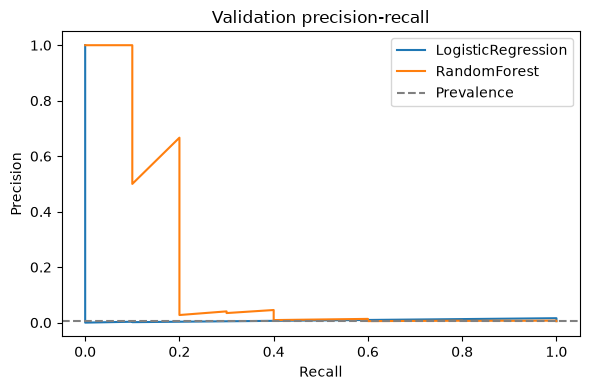

In [4]:
models = {
    'LogisticRegression':Pipeline([('preprocess',preprocessing()),
        ('model',LogisticRegression(class_weight='balanced',max_iter=2000,random_state=SEED))]),
    'RandomForest':Pipeline([('preprocess',preprocessing()),
        ('model',RandomForestClassifier(n_estimators=200,max_depth=6,min_samples_leaf=5,
                     class_weight='balanced_subsample',random_state=SEED,n_jobs=2))])
}
validation_scores = {}
comparison = []
for name,model in models.items():
    model.fit(X_train,y_train)
    scores = model.predict_proba(X_valid)[:,1]
    validation_scores[name] = scores
    comparison.append({'model':name,'validation_AP':average_precision_score(y_valid,scores)})
comparison = pd.DataFrame(comparison).sort_values('validation_AP',ascending=False)
best_name = comparison.iloc[0]['model']
best_model = models[best_name]
print('모델 선택:',best_name)
display(comparison)
fig,ax = plt.subplots(figsize=(6,4))
for name,scores in validation_scores.items():
    precision,recall,_ = precision_recall_curve(y_valid,scores)
    ax.plot(recall,precision,label=name)
ax.axhline(y_valid.mean(),linestyle='--',color='gray',label='Prevalence')
ax.set(xlabel='Recall',ylabel='Precision',title='Validation precision-recall')
ax.legend(); fig.tight_layout(); plt.show()

## 4. 검사 부담을 고려한 판정 기준

점수가 임계값 이상인 생산 건을 추가 검사 대상으로 가정한다. 검사에서 실제 불량을 정확히 확인할 수 있다는 단순한 시나리오다.

- TP: 찾아낸 불량 / FN: 놓친 불량
- FP: 불필요하게 추가 검사한 정상 제품
- TP+FP: 전체 검사 대상
- 재현율: TP/(TP+FN), 정밀도: TP/(TP+FP)

**주 기준:** 검증 데이터의 검사 대상 비율 10% 이내에서 TP가 가장 많은 임계값. 동률이면 FP가 적은 기준, 그다음 높은 임계값을 선택한다. 10%는 실제 현장 요구가 아닌 설명용 가정이다. 같은 규칙의 5%·20%와 기본 0.5도 미리 고정해 비교한다. 검증에서의 검사 비율 제약이 미래 구간에서도 유지된다는 보장은 없다.

,policy,threshold,TP,FN,FP,TN,inspections,inspection_rate,recall,precision
0,default_0.5,0.50000,0,10,0,1827,0,0.000000,0.0,0.000000
1,budget_5pct,0.11896,4,6,84,1743,88,0.047904,0.4,0.045455
2,budget_10pct,0.11896,4,6,84,1743,88,0.047904,0.4,0.045455
3,budget_20pct,0.11896,4,6,84,1743,88,0.047904,0.4,0.045455


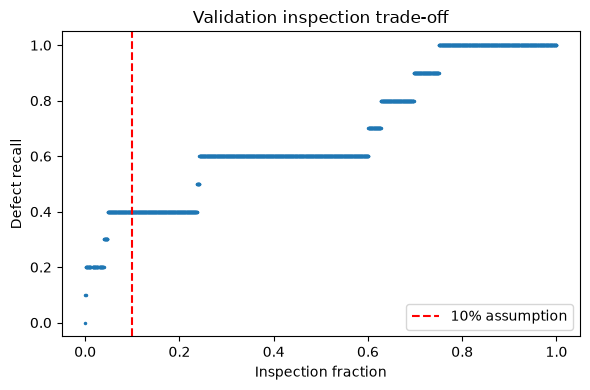

최종 평가 전에 고정한 임계값: 0.11895985940090792


In [5]:
def counts(y,scores,threshold):
    pred = np.asarray(scores)>=threshold
    tn,fp,fn,tp = confusion_matrix(y,pred,labels=[0,1]).ravel()
    return {'threshold':float(threshold),'TP':int(tp),'FN':int(fn),'FP':int(fp),'TN':int(tn),
            'inspections':int(tp+fp),'inspection_rate':float((tp+fp)/len(y)),
            'recall':float(tp/(tp+fn)) if tp+fn else np.nan,
            'precision':float(tp/(tp+fp)) if tp+fp else 0.0}
v_scores = validation_scores[best_name]
threshold_grid = np.r_[np.nextafter(v_scores.max(),np.inf),np.unique(v_scores)]
threshold_table = pd.DataFrame([counts(y_valid,v_scores,t) for t in threshold_grid])
def choose_threshold(budget):
    eligible = threshold_table.loc[threshold_table.inspection_rate<=budget]
    return float(eligible.sort_values(['TP','FP','threshold'],ascending=[False,True,False]).iloc[0].threshold)
policies = {'default_0.5':0.5,'budget_5pct':choose_threshold(0.05),
            'budget_10pct':choose_threshold(INSPECTION_BUDGET),'budget_20pct':choose_threshold(0.20)}
chosen_threshold = policies['budget_10pct']
display(pd.DataFrame([{'policy':k,**counts(y_valid,v_scores,t)} for k,t in policies.items()]))
fig,ax = plt.subplots(figsize=(6,4))
ax.plot(threshold_table.inspection_rate,threshold_table.recall,'.',markersize=3)
ax.axvline(INSPECTION_BUDGET,color='red',linestyle='--',label='10% assumption')
ax.set(xlabel='Inspection fraction',ylabel='Defect recall',title='Validation inspection trade-off')
ax.legend(); fig.tight_layout(); plt.show()
print('최종 평가 전에 고정한 임계값:',chosen_threshold)

## 5. 고정한 모델과 기준으로 최종 평가

아래 결과를 보고 모델·임계값·변수·날짜 경계를 다시 고르지 않는다. 전부 양품 판정과 전수 검사도 참고 기준으로 표시한다. 전수 검사는 예측 모델이 아니라 검사 시나리오다.

,policy,threshold,TP,FN,FP,TN,inspections,inspection_rate,recall,precision
0,all_pass,inf,0,8,0,992,0,0.000,0.000,0.000000
1,default_0.5,0.50000,1,7,5,987,6,0.006,0.125,0.166667
2,budget_5pct,0.11896,2,6,35,957,37,0.037,0.250,0.054054
3,budget_10pct,0.11896,2,6,35,957,37,0.037,0.250,0.054054
4,budget_20pct,0.11896,2,6,35,957,37,0.037,0.250,0.054054
5,inspect_all,-inf,8,0,992,0,1000,1.000,1.000,0.008000


최종 평가 AP: 0.1039 평가 불량 비율: 0.008
주 기준: 불량 8건 중 2건 탐지, 6건 미탐
정상 추가 검사 35건, 전체 검사 37건/1000건
0.5 대비: 불량 탐지 +1건, 정상 추가 검사 +30건


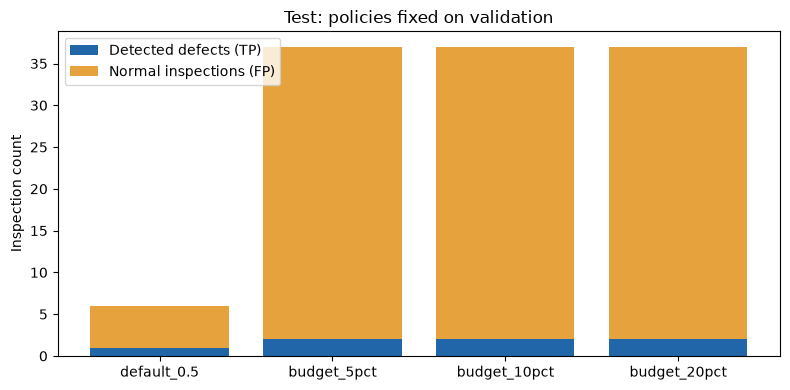

In [6]:
test_scores = best_model.predict_proba(X_test)[:,1]
test_policies = {'all_pass':np.inf,**policies,'inspect_all':-np.inf}
test_results = pd.DataFrame([{'policy':k,**counts(y_test,test_scores,t)} for k,t in test_policies.items()])
test_ap = float(average_precision_score(y_test,test_scores))
display(test_results)
print('최종 평가 AP:',round(test_ap,4),'평가 불량 비율:',round(float(y_test.mean()),4))
chosen = test_results.set_index('policy').loc['budget_10pct']
default = test_results.set_index('policy').loc['default_0.5']
print(f"주 기준: 불량 {int(y_test.sum())}건 중 {int(chosen.TP)}건 탐지, {int(chosen.FN)}건 미탐")
print(f"정상 추가 검사 {int(chosen.FP)}건, 전체 검사 {int(chosen.inspections)}건/{len(test)}건")
print(f"0.5 대비: 불량 탐지 {int(chosen.TP-default.TP):+d}건, 정상 추가 검사 {int(chosen.FP-default.FP):+d}건")
assert all(test_results[['TP','FN','FP','TN']].sum(axis=1)==len(test))
assert all(test_results.TP+test_results.FN==int(y_test.sum()))
fig,ax = plt.subplots(figsize=(8,4))
plot_rows = test_results.set_index('policy').loc[list(policies)]
ax.bar(plot_rows.index,plot_rows.TP,label='Detected defects (TP)',color='#2266aa')
ax.bar(plot_rows.index,plot_rows.FP,bottom=plot_rows.TP,label='Normal inspections (FP)',color='#e6a23c')
ax.set(ylabel='Inspection count',title='Test: policies fixed on validation')
ax.legend(); fig.tight_layout(); plt.show()

## 6. 점검 변수 후보와 미탐 사례

변수 하나를 섞었을 때 검증 AP가 얼마나 감소하는지 확인한다. 모델·기준 변경에는 사용하지 않는다. 중요도는 인과관계가 아니며, 상관된 변수들은 서로 대체되어 중요도가 작게 나올 수 있다. 제품 구분이 중요하면 공정 원인이 아니라 제품 구성 차이일 수 있다.

미탐의 주요 수치 변수를 **같은 제품의 학습 양품 중앙값**과 비교한다. 편차는 학습 양품의 사분위 범위(IQR)로 나눈다. 통계적인 비교 단위이며 공정 허용 한계가 아니다. `Reason`은 여기서 검사 후 사례 설명에만 사용한다.

,feature,AP_drop_mean,AP_drop_std
5,Cushion_Position,0.160456,0.000130
3,Cycle_Time,0.136259,0.004380
15,Average_Back_Pressure,0.123446,0.007444
14,Max_Back_Pressure,0.115474,0.018147
13,Max_Switch_Over_Pressure,0.081142,0.024882
4,Clamp_Close_Time,0.069649,0.054836
11,Average_Screw_RPM,0.065418,0.016360
12,Max_Injection_Pressure,0.063249,0.013402
2,Plasticizing_Time,0.060385,0.031105
10,Max_Screw_RPM,0.045610,0.030808


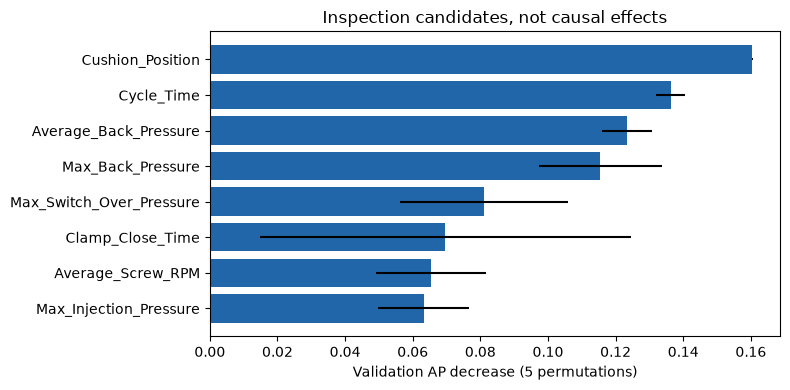

outcome,FN,FP,TN,TP
PART_NAME,,,,
CN7 W/S SIDE MLD'G LH,1,0,462,0
CN7 W/S SIDE MLD'G RH,0,0,463,0
"RG3 MOLD'G W/SHLD, LH",5,0,32,0
"RG3 MOLD'G W/SHLD, RH",0,35,0,2


,TimeStamp,PART_NAME,Reason,score
4724,2020-11-03 04:44:17,CN7 W/S SIDE MLD'G LH,미성형,0.078186
5186,2020-11-04 05:19:50,"RG3 MOLD'G W/SHLD, LH",미성형,0.090212
5188,2020-11-04 05:20:51,"RG3 MOLD'G W/SHLD, LH",미성형,0.073346
5189,2020-11-04 05:21:53,"RG3 MOLD'G W/SHLD, LH",가스,0.102739
5203,2020-11-04 05:32:10,"RG3 MOLD'G W/SHLD, LH",가스,0.114195
5205,2020-11-04 05:33:13,"RG3 MOLD'G W/SHLD, LH",가스,0.094730


,time,part,feature,missed_value,train_normal_median,deviation_in_IQR
0,2020-11-03 04:44:17,CN7 W/S SIDE MLD'G LH,Cushion_Position,653.429993,653.409973,2.000000
1,2020-11-03 04:44:17,CN7 W/S SIDE MLD'G LH,Cycle_Time,59.520000,59.520000,0.000000
2,2020-11-03 04:44:17,CN7 W/S SIDE MLD'G LH,Average_Back_Pressure,59.900002,59.500000,1.333342
3,2020-11-04 05:19:50,"RG3 MOLD'G W/SHLD, LH",Cushion_Position,654.250000,654.250000,0.000000
4,2020-11-04 05:19:50,"RG3 MOLD'G W/SHLD, LH",Cycle_Time,61.779999,61.779999,0.000000
5,2020-11-04 05:19:50,"RG3 MOLD'G W/SHLD, LH",Average_Back_Pressure,62.400002,60.900002,2.142855
6,2020-11-04 05:20:51,"RG3 MOLD'G W/SHLD, LH",Cushion_Position,654.260010,654.250000,0.500000
7,2020-11-04 05:20:51,"RG3 MOLD'G W/SHLD, LH",Cycle_Time,61.779999,61.779999,0.000000
8,2020-11-04 05:20:51,"RG3 MOLD'G W/SHLD, LH",Average_Back_Pressure,62.400002,60.900002,2.142855
9,2020-11-04 05:21:53,"RG3 MOLD'G W/SHLD, LH",Cushion_Position,654.219971,654.250000,-1.500000


미탐이 없더라도 이 소규모 평가에서만 관측되지 않은 것이며 일반적 무미탐을 뜻하지 않습니다.


In [7]:
importance = permutation_importance(best_model,X_valid,y_valid,scoring='average_precision',
    n_repeats=5,random_state=SEED,n_jobs=1)
importance_table = pd.DataFrame({'feature':features,'AP_drop_mean':importance.importances_mean,
    'AP_drop_std':importance.importances_std}).sort_values('AP_drop_mean',ascending=False)
display(importance_table.head(10))
fig,ax = plt.subplots(figsize=(8,4))
top = importance_table.head(8).iloc[::-1]
ax.barh(top.feature,top.AP_drop_mean,xerr=top.AP_drop_std,color='#2266aa')
ax.set(xlabel='Validation AP decrease (5 permutations)',title='Inspection candidates, not causal effects')
fig.tight_layout(); plt.show()
scored = test.copy()
scored['score'] = test_scores
scored['predicted_defect'] = (test_scores>=chosen_threshold).astype(int)
scored['outcome'] = np.select([
    scored.defect.eq(1)&scored.predicted_defect.eq(0),
    scored.defect.eq(1)&scored.predicted_defect.eq(1),
    scored.defect.eq(0)&scored.predicted_defect.eq(1)],['FN','TP','FP'],default='TN')
display(scored.groupby(['PART_NAME','outcome']).size().unstack(fill_value=0))
missed = scored.loc[scored.outcome.eq('FN')]
display(missed[['TimeStamp','PART_NAME','Reason','score']])
top_numeric = [c for c in importance_table.feature if c in numeric][:3]
case_rows = []
for _,row in missed.iterrows():
    normal = train.loc[train.defect.eq(0)&train.PART_NAME.eq(row.PART_NAME)]
    for feature in top_numeric:
        median = normal[feature].median()
        iqr = normal[feature].quantile(.75)-normal[feature].quantile(.25)
        case_rows.append({'time':str(row.time),'part':row.PART_NAME,'feature':feature,
            'missed_value':float(row[feature]),'train_normal_median':float(median),
            'deviation_in_IQR':float((row[feature]-median)/iqr) if iqr else None})
case_table = pd.DataFrame(case_rows)
display(case_table)
print('미탐이 없더라도 이 소규모 평가에서만 관측되지 않은 것이며 일반적 무미탐을 뜻하지 않습니다.')

## 첫 실행 결과 해석 (제공 원본 기준)

주 기준의 최종 평가 결과는 불량 8건 중 TP 2건, FN 6건, FP 35건이다. 기본 0.5 대비 TP가 1건 늘고 FP가 30건 늘었다. 검증의 5%·10%·20% 상한 모두 같은 임계값을 선택했다. 해당 상한 이내에서는 더 낮은 기준으로 불량 탐지가 늘지 않아, 동률 중 정상 추가 검사가 가장 적은 기준이 선택된 것이다.

**전체 재현율 증가만으로 성공으로 판단하지 않는다.** 검사 대상으로 잡힌 37건은 모두 RG3 RH였고, 해당 제품의 양품 35건과 불량 2건을 전부 검사했다. RG3 LH 불량 5건은 모두 놓쳤다.

추가로 원본의 분리별 제품 구성을 확인했다. 검증 구간은 CN7만 포함하며, RG3 LH 학습 데이터에는 양품 591건만 있고 불량은 없다. CN7에서 검증한 기준을 RG3에 그대로 적용한 한계와 제품별 라벨 불균형을 함께 기록한다. 이 사실만으로 미탐의 원인을 확정하지는 않는다.

| 제품 | 학습 양품/불량 | 검증 양품/불량 | 평가 양품/불량 |
|---|---:|---:|---:|
| CN7 LH | 601 / 4 | 912 / 5 | 462 / 1 |
| CN7 RH | 593 / 13 | 915 / 5 | 463 / 0 |
| RG3 LH | 591 / 0 | 0 / 0 | 32 / 5 |
| RG3 RH | 566 / 25 | 0 / 0 | 35 / 2 |

이 해석은 저장된 첫 실행 결과의 기록이다. 입력이나 코드를 바꿔 다시 실험하면 새 결과와 구분해 갱신한다. 현재 평가 결과를 보고 모델을 다시 튜닝하지 않았다. 자세한 판단과 출처는 함께 제공한 README에 정리했다.


## 7. 평가 설계 검토와 한계

해석 시 다음 평가 설계 항목을 검토한다.

1. 왜 원본 7,996행을 그대로 무작위 분리하지 않았는가?
2. `Reason`을 넣으면 왜 사용할 수 없는 모델이 되는가?
3. 10% 검사 가정으로 선택한 기준이 실제 평가에서도 10% 이내인가? 초과하면 무엇을 점검해야 하는가?
4. 기본 0.5와 비교해 추가 탐지와 추가 검사의 교환이 납득되는가?
5. 중요한 변수를 조절하면 불량이 줄어든다고 말할 수 있는가?

**해석의 한계**
- 자동차 부품 사출 데이터다. 다른 제조공정에 직접 적용하거나 현장 개선을 검증한 결과가 아니다.
- 공정 요약값을 사용하므로 사출 사이클 종료 후 검사 우선순위를 정하는 시나리오다. 사출 전 불량 예측이나 실시간 제어를 입증하지 않는다.
- 원본도 일부 라벨이 있는 자료다. 관측된 불량 비율을 전체 공장 불량률로 해석하지 않는다.
- 1개 설비·짧은 기간이며 불량 수가 작다. 특히 평가 불량 8건에서는 한 건으로 재현율이 12.5%p 변한다.
- 생산 묶음 누수는 확인했지만 공정 조건의 시간 상관과 품질 라벨 신뢰성은 남은 한계다.
- 검사 시간·불량 유출 비용이 없어 비용 절감액은 계산하지 않는다. 추가 검사 건수만 비교한다.
- 가이드북의 알고리즘 권장·메일 안내는 참고자료의 내용이다. 이 노트북은 이메일을 발송하지 않는다.

## 출처
중소벤처기업부, Korea AI Manufacturing Platform(KAMP), 사출성형기 AI 데이터셋, KAIST(울산과학기술원, ㈜이피엠솔루션즈), 2020.12.14., https://www.kamp-ai.kr/

참고: 제공된 「사출성형기 AI 데이터셋」 분석실습 가이드북, 데이터 속성 및 Y/N 변환 설명. 원자료와 가이드북은 결과물에 재포함하지 않았다. 연구/공식 활용 시 출처 표기와 활용 내용·문서의 이메일 안내(kamp@kaist.ac.kr)는 제공 자료를 확인한다.

In [8]:
# 선택 사항: 숫자를 파일로 보관. 일반 실행에서는 추가 파일을 만들지 않는다.
# 로컬 검증에서는 MOLDING_RESULT_DIR를 지정하여 README용 결과를 저장한다.
if os.environ.get('MOLDING_RESULT_DIR'):
    result_dir = Path(os.environ['MOLDING_RESULT_DIR'])
    result_dir.mkdir(parents=True,exist_ok=True)
    summary = {'source_sha256':source_sha256,'audit':audit.to_dict('records'),
        'splits':split_table.to_dict('records'),'best_model':best_name,
        'validation_models':comparison.to_dict('records'),'policies':policies,
        'test_AP':test_ap,'test_results':test_results.replace([np.inf,-np.inf],np.nan).to_dict('records'),
        'importance':importance_table.head(10).to_dict('records'),
        'versions':{'python':platform.python_version(),'pandas':pd.__version__,
                    'numpy':np.__version__,'sklearn':sklearn.__version__}}
    (result_dir/'summary.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')
    scored[['TimeStamp','PART_NAME','Reason','defect','score','outcome']].to_csv(result_dir/'test_cases.csv',index=False)
    for number in plt.get_fignums():
        plt.figure(number).savefig(result_dir/f'figure_{number}.png',dpi=140,bbox_inches='tight')
print('분석 완료. 모델·임계값은 검증 데이터에서만 선택했습니다.')

분석 완료. 모델·임계값은 검증 데이터에서만 선택했습니다.
